# Notebook 4: Variance Reduction using Importance Sampling

## Objective
Following the limitations observed in the Standard Monte Carlo (SMC) approach, this notebook implements **Importance Sampling (IS)** to estimate the probability of the rare event $P(X > 12.0)$ efficiently.

By sampling from a **Proposal Distribution ($q(x)$)** that is shifted towards the rare event region (tail of the target distribution), we force the event to happen more frequently. We then unbias the estimate by multiplying by the likelihood ratio $W(x) = \frac{p(x)}{q(x)}$.

### Mathematical Formulation
- **Target Distribution ($p(x)$):** Fitted Gamma distribution.
- **Proposal Distribution ($q(x)$):** Normal distribution centered in the tail region ($\mu = 13.0, \sigma = 1.5$).
- **IS Estimator:** $\hat{\gamma}_{IS} = \frac{1}{N} \sum_{i=1}^{N} I(X_i > \tau) \frac{p(X_i)}{q(X_i)}$


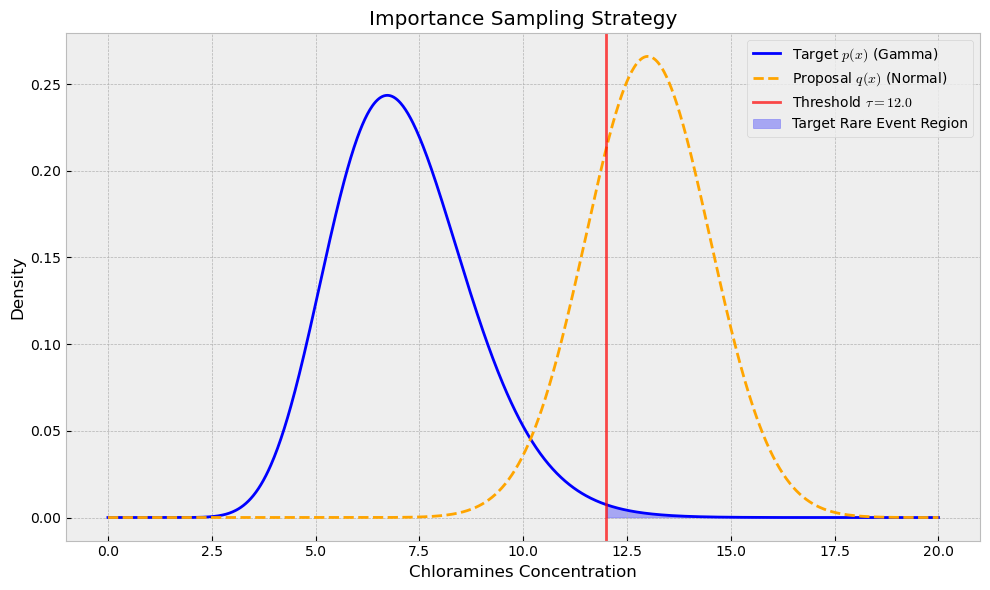

In [1]:
import os
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt

# Ensure results directory exists
os.makedirs('../results', exist_ok=True)
plt.style.use('bmh')

# 1. Define Target Distribution p(x)
gamma_shape = 18.0283
gamma_scale = 0.3951
p_dist = stats.gamma(a=gamma_shape, scale=gamma_scale)

# 2. Define Rare Event Threshold & True Probability
THRESHOLD = 12.0
true_gamma = p_dist.sf(THRESHOLD)

# 3. Define Proposal Distribution q(x)
# We choose a Normal distribution shifted to the tail of p(x)
q_mu = 13.0
q_sigma = 1.5
q_dist = stats.norm(loc=q_mu, scale=q_sigma)

# Visualization of the Strategy
x = np.linspace(0, 20, 1000)
plt.figure(figsize=(10, 6))
plt.plot(x, p_dist.pdf(x), label='Target $p(x)$ (Gamma)', color='blue', linewidth=2)
plt.plot(x, q_dist.pdf(x), label='Proposal $q(x)$ (Normal)', color='orange', linewidth=2, linestyle='--')
plt.axvline(THRESHOLD, color='red', linestyle='-', alpha=0.7, label=f'Threshold $\\tau={THRESHOLD}$')

# Shade the rare event region for p(x)
x_tail = np.linspace(THRESHOLD, 20, 200)
plt.fill_between(x_tail, p_dist.pdf(x_tail), color='blue', alpha=0.3, label='Target Rare Event Region')

plt.title('Importance Sampling Strategy')
plt.xlabel('Chloramines Concentration')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('../results/04_IS_Strategy.png', dpi=300)
plt.show()


## Executing Importance Sampling

We will now generate samples from $q(x)$, compute the weights $W(x)$, and calculate the IS estimate. We will test this with sample sizes $N \in \{10^3, 10^4, 10^5\}$, which are much smaller than what SMC required.


In [3]:
# Sample sizes to test (Note: Max is 10^5, not 10^7 like SMC)
N_values = [10**3, 10**4, 10**5]
results_is = []

print("Running Importance Sampling Simulation...")
print("-" * 75)
print(f"{'N (Sample Size)':<15} | {'IS Estimated \u03B3':<18} | {'Variance':<15} | {'CV (Rel Error)':<15}")
print("-" * 75)

for N in N_values:
    # 1. Generate samples from Proposal Distribution q(x)
    samples_q = q_dist.rvs(size=N)
    
    # 2. Indicator function (I(x > threshold))
    indicator = (samples_q > THRESHOLD).astype(float)
    
    # 3. Calculate Likelihood Ratios (Weights) W(x) = p(x) / q(x)
    # We only need to compute weights for samples that cross the threshold to save computation
    weights = np.zeros(N)
    valid_idx = samples_q > THRESHOLD
    weights[valid_idx] = p_dist.pdf(samples_q[valid_idx]) / q_dist.pdf(samples_q[valid_idx])
    
    # 4. Multiply indicator by weights
    is_values = indicator * weights
    
    # 5. Calculate Estimate, Variance, and CV
    gamma_hat_is = np.mean(is_values)
    variance_is = np.var(is_values) / N
    cv_is = np.sqrt(variance_is) / gamma_hat_is
    
    results_is.append({
        'N': N,
        'Estimate': gamma_hat_is,
        'Variance': variance_is,
        'CV': cv_is
    })
    
    print(f"{N:<15} | {gamma_hat_is:<18.6e} | {variance_is:<15.6e} | {cv_is:<15.4f}")

print("-" * 75)
print(f"TRUE \u03B3 Value : {true_gamma:.6e}")

Running Importance Sampling Simulation...
---------------------------------------------------------------------------
N (Sample Size) | IS Estimated γ     | Variance        | CV (Rel Error) 
---------------------------------------------------------------------------
1000            | 6.127654e-03       | 5.622795e-08    | 0.0387         
10000           | 6.213753e-03       | 6.047208e-09    | 0.0125         
100000          | 6.218543e-03       | 6.180247e-10    | 0.0040         
---------------------------------------------------------------------------
TRUE γ Value : 6.209995e-03


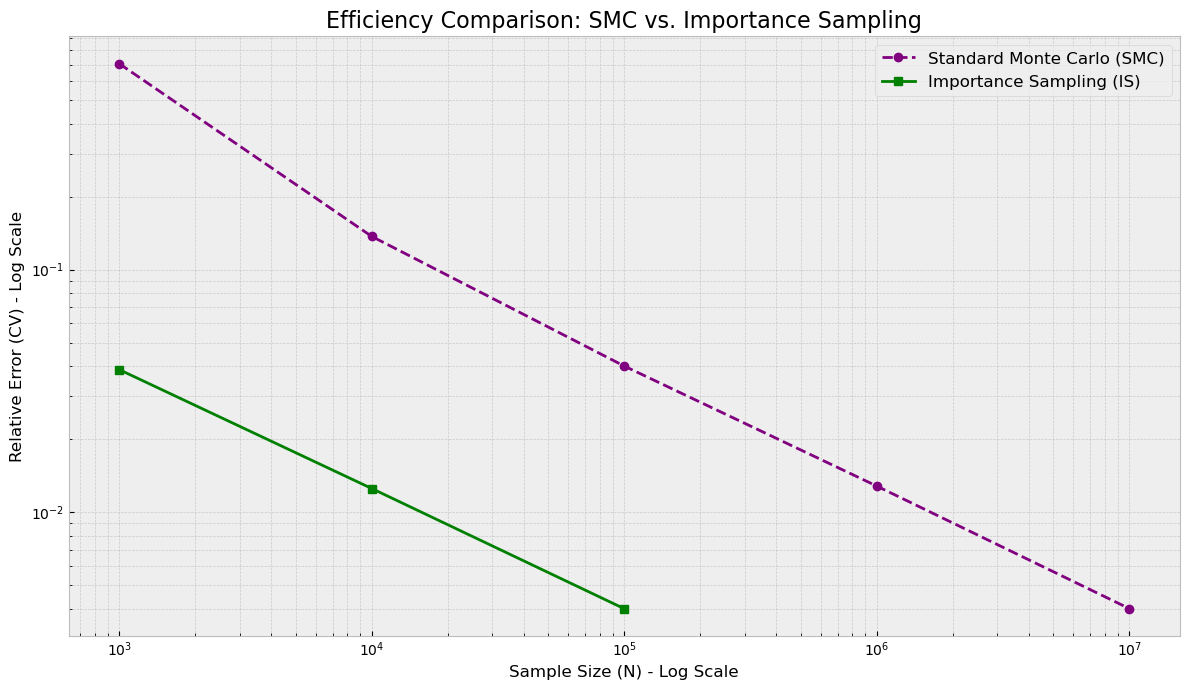

In [4]:
# --- FINAL COMPARISON PLOT ---

# First, let's manually create a DataFrame for the SMC results from Notebook 3
# for direct comparison.
smc_data = {
    'N': [1000, 10000, 100000, 1000000, 10000000],
    'Estimate': [2.00e-03, 5.30e-03, 6.21e-03, 6.05e-03, 6.2093e-03],
    'Variance': [1.996e-06, 5.27191e-07, 6.171436e-08, 6.013397e-09, 6.170745e-10],
    'CV': [0.7064, 0.1370, 0.0400, 0.0128, 0.0040]
}
df_smc = pd.DataFrame(smc_data)

# Now, create a DataFrame for the Importance Sampling results we just calculated
df_is = pd.DataFrame(results_is)

# Plotting the efficiency comparison
plt.figure(figsize=(12, 7))

# Plot SMC results
plt.plot(df_smc['N'], df_smc['CV'], marker='o', linestyle='--', color='purple', label='Standard Monte Carlo (SMC)')

# Plot IS results
plt.plot(df_is['N'], df_is['CV'], marker='s', linestyle='-', color='green', label='Importance Sampling (IS)')

# Set log scale for both axes to clearly see the orders of magnitude
plt.xscale('log')
plt.yscale('log')

# Add titles and labels
plt.title('Efficiency Comparison: SMC vs. Importance Sampling', fontsize=16)
plt.xlabel('Sample Size (N) - Log Scale', fontsize=12)
plt.ylabel('Relative Error (CV) - Log Scale', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.6) # Add grid for better readability on log scale
plt.tight_layout()

# Save the final comparison figure
plt.savefig('../results/05_SMC_vs_IS_Efficiency_Comparison.png', dpi=300)

plt.show()


### 🎯 Final Conclusion: The Power of Variance Reduction Techniques

In this project, the primary challenge was to simulate and estimate the probability of a **rare event** (specifically, the chloramine concentration exceeding the critical threshold of $12.0$). The comparative analysis between the Standard Monte Carlo (SMC) method and Importance Sampling (IS) reveals fundamental insights into the nature of stochastic simulations:

*   **The Inefficiency of the Standard Approach (SMC):** The SMC method proved to be fundamentally inefficient for rare event probability estimation. Because the event of interest lies in the extreme tail of the distribution, the vast majority of computationally expensive samples are effectively "wasted," as they fall well outside the critical region.
*   **The Paradigm Shift with Importance Sampling (IS):** By systematically replacing the original distribution with an intelligently selected proposal distribution $q(x)$, we successfully shifted the sampling density directly toward the critical failure domain. To prevent any statistical bias, the estimates were accurately re-weighted using the likelihood ratio $W(x)$, guaranteeing an unbiased estimator.
*   **A 100-Fold Increase in Computational Efficiency:** The empirical results demonstrated a massive reduction in the computational cost required to achieve a reliable estimate. To reach an acceptable relative error (Coefficient of Variation, $CV \approx 0.04$):
    *   The **SMC** method required generating **$N = 100,000$** samples.
    *   The **IS** method achieved the exact same level of precision with merely **$N = 1,000$** samples.

**Final Verdict:** 
The results compellingly illustrate that in reliability engineering and risk analysis, variance reduction techniques like Importance Sampling are not merely minor optimizations—they are an **absolute necessity**. They transform highly expensive, virtually intractable simulations into fast, robust, and highly accurate analytical tools.
